# Extension 2 -- Causal Heterogeneity (DR-Learner)

**Research question.** Among observed patient and contextual characteristics, where does the adjusted private-vs-public Cesarean contrast appear larger or smaller?

**Relationship to the frozen V2 pipeline.** This notebook does not modify anything under `notebooks/v2/` or `outputs/`. It reuses the same public/private analytic cohort, the same 8-variable confounder set, and -- where available -- the exact cross-fitted nuisance predictions already produced by `notebooks/v2/07_aipw_primary_analysis.ipynb` (`outputs/tables/b4_aipw_row_level_nuisance.csv`, a local, gitignored, row-level file). If that file isn't present locally, this notebook falls back to an independent re-fit using identical machinery (`extensions_work/shared/utils.py`), and says so explicitly -- the two paths are not silently interchangeable.

**Method, stated up front.** This is an "honest" DR-learner (Kennedy, 2020): compute the doubly-robust AIPW pseudo-outcome for the sector contrast for every record (using out-of-fold nuisance predictions, so no model ever scores data it was trained on), then regress that pseudo-outcome on a *pre-specified* set of pre-exposure moderators using a second, independently cross-fitted model. A plain `RandomForestRegressor` is used as the second-stage learner rather than a dedicated causal-forest package (`econml`/`grf`) -- this keeps the extension dependency-free (no new package beyond what's already in `requirements.txt`) and transparent, and is a standard, citable instantiation of the DR-learner framework, not a shortcut.

**Interpretation rule, repeated at the end:** any heterogeneity found here is *exploratory adjusted-effect heterogeneity*, not personalized causal truth, and is only as credible as the primary AIPW analysis's own selection-on-observables assumption.

**Not run here.** Written but not executed -- this sandbox has no NFHS data. Run it locally where `data/processed/df_model_v2.parquet` (and, if available, `outputs/tables/b4_aipw_row_level_nuisance.csv`) already exist.

## 1. Imports, shared config/utils

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder

sys.path.append(str(Path("../shared").resolve()))
import config
import utils

pd.set_option("display.max_columns", None)

OUTPUTS_DIR = config.EXT02_OUTPUTS_DIR
RANDOM_STATE = config.RANDOM_STATE
N_FOLDS = config.N_FOLDS

## 2. Load the same public/private analytic cohort as Notebook 07

In [2]:
analytic, n_loaded, n_other = utils.load_public_private_analytic(
    config.V2_PROCESSED_DATA_PATH,
    expected_total_rows=config.EXPECTED_V2_ROW_COUNT,
    expected_analytic_rows=config.EXPECTED_ANALYTIC_ROW_COUNT,
)
print(f"Loaded df_model_v2: {n_loaded} rows. Excluded 'other' facility records: {n_other}.")
print(f"Analytic sample (public + private): {len(analytic)}")
print(analytic["exposure"].value_counts().rename({0: "public", 1: "private"}))

Loaded df_model_v2: 201311 rows. Excluded 'other' facility records: 517.
Analytic sample (public + private): 200794
exposure
public     150299
private     50495
Name: count, dtype: int64


## 3. Confounder set for the nuisance models (identical to notebooks/v2/06-07)

In [3]:
numeric_confounders = config.NUMERIC_CONFOUNDERS
categorical_confounders = config.CATEGORICAL_CONFOUNDERS
confounder_cols = config.CONFOUNDER_COLS
print(f"Confounder set ({len(confounder_cols)}): {confounder_cols}")

Confounder set (8): ['birth_order', 'wealth_index', 'education_years', 'residence', 'religion', 'social_group', 'twin_order', 'state']


## 4. Pre-specified moderator set -- fixed BEFORE inspecting any heterogeneity result

Per the handoff (step 15), the moderator set below is decided here, before any CATE model is fit or any heterogeneity result is inspected. See `../shared/data_dictionary.md` for the full rationale for each variable and for what is explicitly excluded (all ANC/service mediators, the exposure itself, and the V2-derived risk-stratum/first_birth columns).

`maternal_age` is kept out of the primary moderator set for the same documented reason it's out of the primary confounder set (notebooks/v2/06-07: `v012` is age-at-interview, not verified age-at-birth). It is available as an optional, clearly labeled sensitivity moderator only (`MATERNAL_AGE_SENSITIVITY`), off by default.

In [4]:
PRIMARY_MODERATORS_NUMERIC = ["wealth_index", "education_years"]
PRIMARY_MODERATORS_CATEGORICAL = ["residence", "social_group", "state", "twin_order"]
PRIMARY_MODERATORS = PRIMARY_MODERATORS_NUMERIC + PRIMARY_MODERATORS_CATEGORICAL

MATERNAL_AGE_SENSITIVITY = False  # optional secondary moderator; see markdown above

forbidden_as_moderator = {
    "anc_visits", "anc_doctor", "anc_nurse_midwife", "anc_traditional_attendant",
    "anc_community_worker", "anc_anganwadi_worker", "anc_asha_worker", "anc_other_provider",
    "no_anc_provider", "first_anc_timing", "weight_measured_during_pregnancy",
    "bp_measured_during_pregnancy", "urine_sample_during_pregnancy", "blood_sample_during_pregnancy",
    "told_about_pregnancy_complications", "counselled_vaginal_bleeding", "counselled_convulsions",
    "counselled_prolonged_labour", "counselled_severe_abdominal_pain", "counselled_high_blood_pressure",
    "facility_type", "delivery_place_code", "csection",
    "risk_stratum_primary", "risk_stratum_refined_sensitivity", "first_birth",
    "convulsions_during_pregnancy", "swelling_during_pregnancy",
}

overlap = forbidden_as_moderator.intersection(set(PRIMARY_MODERATORS))
assert not overlap, f"Forbidden/post-exposure variable found in moderator set: {overlap}"
print(f"Primary moderator set ({len(PRIMARY_MODERATORS)}): {PRIMARY_MODERATORS}")
print("No mediator/post-exposure/forbidden variable in the moderator set.")

Primary moderator set (6): ['wealth_index', 'education_years', 'residence', 'social_group', 'state', 'twin_order']
No mediator/post-exposure/forbidden variable in the moderator set.


## 5. Stage 1 -- reuse Notebook 07's cross-fitted nuisance predictions, or refit identically if unavailable

`outputs/tables/b4_aipw_row_level_nuisance.csv` is a local, gitignored, row-level file produced by `notebooks/v2/07_aipw_primary_analysis.ipynb` when run locally. Reusing it exactly ties this extension's pseudo-outcomes to the same nuisance fit that produced the frozen primary estimate (RD 28.47 pp / RR 2.73). If it isn't present, this notebook refits identical nuisance machinery (`extensions_work/shared/utils.cross_fit_nuisances`) with the same specification, random seed, and fold count -- but the resulting numbers will then be a close, independent re-fit, not an exact match, and this is printed explicitly rather than assumed.

In [5]:
row_level_path = config.V2_FINAL_TABLES_DIR.parent / "tables" / "b4_aipw_row_level_nuisance.csv"
REUSED_NOTEBOOK07_NUISANCES = row_level_path.exists()

if REUSED_NOTEBOOK07_NUISANCES:
    row_level = pd.read_csv(row_level_path)
    merged = analytic.merge(
        row_level[["respondent_id", "exposure", "csection", "e_hat_clipped", "mu1_hat", "mu0_hat",
                   "cluster_number", "sample_stratum_v022", "sample_weight_normalized"]],
        on="respondent_id", how="inner", suffixes=("", "_nb07"),
    )
    # --- Assertion: the reused file must describe the same records, not a different cohort ---
    assert len(merged) == len(analytic), (
        f"Row-level nuisance file covers {len(merged)} of {len(analytic)} analytic records -- "
        f"cohort mismatch. Do not proceed without investigating."
    )
    assert (merged["exposure"] == merged["exposure_nb07"]).all(), "Exposure coding mismatch vs Notebook 07's saved file."
    assert (merged["csection"] == merged["csection_nb07"]).all(), "Outcome coding mismatch vs Notebook 07's saved file."
    analytic = merged.drop(columns=["exposure_nb07", "csection_nb07"])
    e_hat_clipped = analytic["e_hat_clipped"].to_numpy()
    mu1_hat = analytic["mu1_hat"].to_numpy()
    mu0_hat = analytic["mu0_hat"].to_numpy()
    print(f"Reused Notebook 07's cross-fitted nuisance predictions for all {len(analytic)} records.")
else:
    print("outputs/tables/b4_aipw_row_level_nuisance.csv not found locally -- "
          "refitting nuisance models with identical machinery (independent re-fit, not an exact match).")
    W = analytic[confounder_cols].copy()
    for col in categorical_confounders:
        W[col] = W[col].astype("string").fillna("Missing").astype(str)
    e_hat_raw, mu1_hat, mu0_hat, fold_assignments = utils.cross_fit_nuisances(
        W, analytic["exposure"].to_numpy(), analytic["csection"].astype(int).to_numpy(),
        analytic["respondent_id"].to_numpy(), analytic["sample_weight_normalized"].to_numpy(),
        numeric_confounders, categorical_confounders,
        n_folds=N_FOLDS, random_state=RANDOM_STATE, outcome_model_type="xgboost",
    )
    e_hat_clipped = np.clip(e_hat_raw, config.CLIP_EPS, 1 - config.CLIP_EPS)
    analytic["fold"] = fold_assignments

print(f"REUSED_NOTEBOOK07_NUISANCES = {REUSED_NOTEBOOK07_NUISANCES}")

outputs/tables/b4_aipw_row_level_nuisance.csv not found locally -- refitting nuisance models with identical machinery (independent re-fit, not an exact match).
REUSED_NOTEBOOK07_NUISANCES = False


## 6. Sanity check -- does the overall AIPW estimate from these nuisances match the frozen primary result?

In [6]:
outcome = analytic["csection"].astype(int).to_numpy()
exposure = analytic["exposure"].to_numpy()
survey_weight = analytic["sample_weight_normalized"].to_numpy()

r1_hat, r0_hat, risk_difference, risk_ratio = utils.aipw_point_estimate(
    outcome, exposure, e_hat_clipped, mu1_hat, mu0_hat, survey_weight,
)
print(f"This notebook's AIPW risk difference: {risk_difference * 100:.2f} pp | risk ratio: {risk_ratio:.3f}")

frozen_path = config.V2_FINAL_TABLES_DIR / "final_aipw_overall_table.csv"
if frozen_path.exists():
    frozen = pd.read_csv(frozen_path)
    print("\nFrozen primary result (outputs/final_tables/final_aipw_overall_table.csv):")
    print(frozen)
    print(f"\nExpected consistency: {'exact (reused nuisances)' if REUSED_NOTEBOOK07_NUISANCES else 'approximate only (independent re-fit)'}")
else:
    print("outputs/final_tables/final_aipw_overall_table.csv not found locally -- skipping direct comparison.")

This notebook's AIPW risk difference: 28.47 pp | risk ratio: 2.726

Frozen primary result (outputs/final_tables/final_aipw_overall_table.csv):
   r1_hat_private_risk_pct  r0_hat_public_risk_pct  risk_difference_pct  \
0                  44.9644               16.494602            28.469798   

   risk_difference_ci_low_pct  risk_difference_ci_high_pct  risk_ratio  \
0                   27.671957                    29.244259    2.726007   

   risk_ratio_ci_low  risk_ratio_ci_high  n_analytic  n_private  n_public  \
0           2.656604            2.803453      200794      50495    150299   

   n_extreme_propensity  trimmed_sensitivity_rd_pct  trimmed_sensitivity_rr  
0                 17501                         NaN                     NaN  

Expected consistency: approximate only (independent re-fit)


## 7. Per-record AIPW pseudo-outcome for the sector contrast (DR-learner target)

`tau_hat_i = psi1_i - psi0_i` is the standard doubly-robust pseudo-outcome for the individual treatment contrast (Kennedy, 2020). Regressing this quantity on pre-exposure moderators -- rather than regressing the raw outcome separately by arm -- is what makes the second stage a *causal* heterogeneity model rather than an outcome-prediction model.

In [7]:
psi1, psi0 = utils.aipw_psi(outcome, exposure, e_hat_clipped, mu1_hat, mu0_hat)
tau_hat = psi1 - psi0

print("Per-record pseudo-outcome (tau_hat) summary:")
print(pd.Series(tau_hat).describe())
print(f"\nSurvey-weighted mean tau_hat (must equal the risk difference above): "
      f"{np.average(tau_hat, weights=survey_weight) * 100:.2f} pp")

Per-record pseudo-outcome (tau_hat) summary:
count    200794.000000
mean          0.282852
std           1.339049
min         -75.055966
25%           0.175798
50%           0.376631
75%           0.576008
max          88.765644
dtype: float64

Survey-weighted mean tau_hat (must equal the risk difference above): 28.47 pp


## 8. Moderator design matrix (pre-exposure only)

In [8]:
X_mod = analytic[PRIMARY_MODERATORS].copy()
for col in PRIMARY_MODERATORS_CATEGORICAL:
    X_mod[col] = X_mod[col].astype("string").fillna("Missing").astype(str)
for col in PRIMARY_MODERATORS_NUMERIC:
    X_mod[col] = X_mod[col].fillna(X_mod[col].median())

if MATERNAL_AGE_SENSITIVITY:
    X_mod["maternal_age"] = analytic["maternal_age"].fillna(analytic["maternal_age"].median())

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_cat_encoded = encoder.fit_transform(X_mod[PRIMARY_MODERATORS_CATEGORICAL])
cat_feature_names = encoder.get_feature_names_out(PRIMARY_MODERATORS_CATEGORICAL)

numeric_cols_for_model = PRIMARY_MODERATORS_NUMERIC + (["maternal_age"] if MATERNAL_AGE_SENSITIVITY else [])
X_design = np.hstack([X_mod[numeric_cols_for_model].to_numpy(), X_cat_encoded])
feature_names = numeric_cols_for_model + list(cat_feature_names)

print(f"Moderator design matrix: {X_design.shape[0]} records x {X_design.shape[1]} features")
print(f"Features: {feature_names}")

Moderator design matrix: 200794 records x 49 features
Features: ['wealth_index', 'education_years', 'residence_1', 'residence_2', 'social_group_1', 'social_group_2', 'social_group_3', 'social_group_4', 'social_group_Missing', 'state_1', 'state_10', 'state_11', 'state_12', 'state_13', 'state_14', 'state_15', 'state_16', 'state_17', 'state_18', 'state_19', 'state_2', 'state_20', 'state_21', 'state_22', 'state_23', 'state_24', 'state_25', 'state_27', 'state_28', 'state_29', 'state_3', 'state_30', 'state_31', 'state_32', 'state_33', 'state_34', 'state_35', 'state_36', 'state_37', 'state_4', 'state_5', 'state_6', 'state_7', 'state_8', 'state_9', 'twin_order_0', 'twin_order_1', 'twin_order_2', 'twin_order_3']


## 9. Honest second-stage DR-learner -- respondent-grouped cross-fitted CATE regression

A fresh `GroupKFold` split (grouped by `respondent_id`, independent of the Stage 1 folds) fits a `RandomForestRegressor` on `tau_hat` using the moderator design matrix, survey-weighted, and predicts out-of-fold for every record. No record's predicted CATE ever comes from a model that saw that record's own `tau_hat` during training -- this is the "honesty" the handoff requires (step 17).

In [9]:
CATE_N_FOLDS = 5
cate_splitter = GroupKFold(n_splits=CATE_N_FOLDS)
cate_groups = analytic["respondent_id"].to_numpy()

tau_oof = np.full(len(analytic), np.nan)
fold_importances = []

for fold_id, (train_idx, test_idx) in enumerate(cate_splitter.split(X_design, groups=cate_groups)):
    train_groups = set(cate_groups[train_idx])
    test_groups = set(cate_groups[test_idx])
    assert not (train_groups & test_groups), f"CATE fold {fold_id}: respondent overlap between train and held-out."

    cate_model = RandomForestRegressor(
        n_estimators=500, max_depth=6, min_samples_leaf=200,
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    cate_model.fit(X_design[train_idx], tau_hat[train_idx], sample_weight=survey_weight[train_idx])
    tau_oof[test_idx] = cate_model.predict(X_design[test_idx])
    fold_importances.append(cate_model.feature_importances_)

assert not np.isnan(tau_oof).any(), "Every record must receive an out-of-fold CATE prediction."
print(f"Honest out-of-fold CATE predictions produced for all {len(tau_oof)} records across {CATE_N_FOLDS} folds.")
print(pd.Series(tau_oof).describe())

Honest out-of-fold CATE predictions produced for all 200794 records across 5 folds.
count    200794.000000
mean          0.283126
std           0.093688
min          -0.090984
25%           0.290429
50%           0.301373
75%           0.303882
max           0.830484
dtype: float64


## 10. Variable importance for treatment-effect heterogeneity (not outcome prediction)

Because the second-stage model's target is `tau_hat` (already a causal contrast, not the raw outcome), its feature importances describe what predicts *heterogeneity in the sector effect*, not what predicts C-section risk in general -- the distinction the handoff's QA check (step 19) requires.

In [10]:
importance_matrix = np.vstack(fold_importances)
modifier_summary = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": importance_matrix.mean(axis=0),
    "importance_std": importance_matrix.std(axis=0),
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)
modifier_summary["rank"] = modifier_summary.index + 1

modifier_summary.to_csv(OUTPUTS_DIR / "heterogeneity_modifier_summary.csv", index=False)
print("Saved:", OUTPUTS_DIR / "heterogeneity_modifier_summary.csv")
modifier_summary

Saved: C:\Users\rifan\Downloads\IPD_SEM_5\IPD\extensions_work\02_causal_heterogeneity\outputs\heterogeneity_modifier_summary.csv


,feature,importance_mean,importance_std,rank
0,state_19,3.322608e-01,2.181779e-02,1
1,state_8,9.151155e-02,6.669392e-03,2
2,state_21,8.739579e-02,1.742037e-02,3
3,state_32,8.683207e-02,1.245037e-02,4
4,state_24,8.531275e-02,7.988652e-03,5
5,state_27,8.360201e-02,9.324175e-03,6
6,education_years,7.044063e-02,9.102435e-03,7
7,wealth_index,5.452748e-02,4.464713e-03,8
8,residence_1,2.702129e-02,5.738514e-03,9
9,residence_2,2.201062e-02,1.113962e-02,10


## 11. Calibration / ranking check -- sorted-quantile-bin realized AIPW effect vs. predicted CATE

Standard honest-CATE validation (a "sorted group ATE" / calibration check): bin records into quintiles of the out-of-fold predicted `tau_oof`, then estimate the *realized* AIPW risk difference within each bin using the already-computed nuisance predictions, with a PSU-cluster bootstrap CI. If the model captures real heterogeneity, realized effects should rank in the same order as the predicted quintiles; if they don't, heterogeneity is weak/null and is reported as such (step 20 / QA rule). Pre-specified categorical subgroups (`residence`, `social_group`) are summarized the same way, alongside the quintile bins, in one aggregate table.

In [11]:
N_QUANTILE_BINS = 5
analytic["tau_oof"] = tau_oof
analytic["cate_quintile"] = pd.qcut(tau_oof, N_QUANTILE_BINS, labels=[f"Q{i+1}" for i in range(N_QUANTILE_BINS)])

rng = np.random.RandomState(config.BOOTSTRAP_SEED)


def bootstrap_bin_rd(mask, grouping_var, group_label):
    y_b = outcome[mask]
    a_b = exposure[mask]
    e_b = e_hat_clipped[mask]
    mu1_b = mu1_hat[mask]
    mu0_b = mu0_hat[mask]
    w_b = survey_weight[mask]
    psu_b = analytic.loc[mask, "cluster_number"].to_numpy()
    stratum_b = analytic.loc[mask, "sample_stratum_v022"].to_numpy()

    r1_b, r0_b, rd_b, rr_b = utils.aipw_point_estimate(y_b, a_b, e_b, mu1_b, mu0_b, w_b)

    boot_rds = np.empty(config.N_BOOTSTRAP)
    for rep in range(config.N_BOOTSTRAP):
        idx = utils.resample_indices_within_strata(psu_b, stratum_b, rng)
        _, _, rd_rep, _ = utils.aipw_point_estimate(y_b[idx], a_b[idx], e_b[idx], mu1_b[idx], mu0_b[idx], w_b[idx])
        boot_rds[rep] = rd_rep

    return {
        "grouping_variable": grouping_var, "group_label": group_label,
        "n": int(mask.sum()), "mean_predicted_tau_pp": float(np.average(tau_oof[mask], weights=w_b) * 100),
        "realized_aipw_rd_pp": rd_b * 100,
        "realized_aipw_rd_ci_low_pp": float(np.percentile(boot_rds, 2.5) * 100),
        "realized_aipw_rd_ci_high_pp": float(np.percentile(boot_rds, 97.5) * 100),
        "realized_aipw_rr": rr_b,
    }


bin_rows = []
for label in [f"Q{i+1}" for i in range(N_QUANTILE_BINS)]:
    mask = (analytic["cate_quintile"] == label).to_numpy()
    bin_rows.append(bootstrap_bin_rd(mask, "cate_predicted_quintile", label))

for grouping_var in ["residence", "social_group"]:
    for level in sorted(analytic[grouping_var].dropna().unique(), key=str):
        mask = (analytic[grouping_var] == level).fillna(False).to_numpy()
        if mask.sum() < 30:
            continue
        bin_rows.append(bootstrap_bin_rd(mask, grouping_var, str(level)))

heterogeneity_summary = pd.DataFrame(bin_rows)
heterogeneity_summary.to_csv(OUTPUTS_DIR / "heterogeneity_individual_or_binned_summary.csv", index=False)
print("Saved:", OUTPUTS_DIR / "heterogeneity_individual_or_binned_summary.csv")
heterogeneity_summary


Saved: C:\Users\rifan\Downloads\IPD_SEM_5\IPD\extensions_work\02_causal_heterogeneity\outputs\heterogeneity_individual_or_binned_summary.csv


,grouping_variable,group_label,n,mean_predicted_tau_pp,realized_aipw_rd_pp,realized_aipw_rd_ci_low_pp,realized_aipw_rd_ci_high_pp,realized_aipw_rr
0,cate_predicted_quintile,Q1,40233,14.806002,14.814930,13.368621,16.405035,1.844542
1,cate_predicted_quintile,Q2,42480,29.368991,26.419448,24.851877,27.999904,2.219327
2,cate_predicted_quintile,Q3,47694,30.208307,32.047417,30.475830,33.570821,3.427104
3,cate_predicted_quintile,Q4,35370,30.405367,31.527584,29.546919,33.574274,3.981057
4,cate_predicted_quintile,Q5,35017,41.465363,42.039437,40.469509,43.568490,3.470446
5,residence,1,44077,25.228426,22.558258,21.076591,24.117205,1.903807
6,residence,2,156717,29.751204,30.793268,30.002710,31.714106,3.338546
7,social_group,1,41760,30.170819,30.189831,28.559579,31.885527,2.999602
8,social_group,2,35221,26.574197,27.060468,24.833096,29.334473,3.702551
9,social_group,3,79890,27.150250,26.752255,25.652514,27.699986,2.623942


## 12. Monotonicity check and honest heterogeneity verdict

In [12]:
quintile_rows = heterogeneity_summary[heterogeneity_summary["grouping_variable"] == "cate_predicted_quintile"].sort_values("group_label")
is_monotonic = quintile_rows["realized_aipw_rd_pp"].is_monotonic_increasing
ci_overlap_extremes = (
    quintile_rows["realized_aipw_rd_ci_low_pp"].iloc[-1] <= quintile_rows["realized_aipw_rd_ci_high_pp"].iloc[0]
)

print(f"Realized AIPW RD increases monotonically from Q1 to Q5: {is_monotonic}")
print(f"Q1 and Q5 confidence intervals overlap: {ci_overlap_extremes}")
if is_monotonic and not ci_overlap_extremes:
    print("VERDICT: heterogeneity across the predicted-CATE quintiles is directionally consistent and "
          "the extreme quintiles do not overlap -- report as suggestive exploratory heterogeneity.")
else:
    print("VERDICT: heterogeneity is weak/inconsistent across predicted-CATE quintiles on this run -- "
          "report honestly as null/weak rather than overstating a pattern (per QA rule).")

Realized AIPW RD increases monotonically from Q1 to Q5: False
Q1 and Q5 confidence intervals overlap: False
VERDICT: heterogeneity is weak/inconsistent across predicted-CATE quintiles on this run -- report honestly as null/weak rather than overstating a pattern (per QA rule).


## 13. Figures

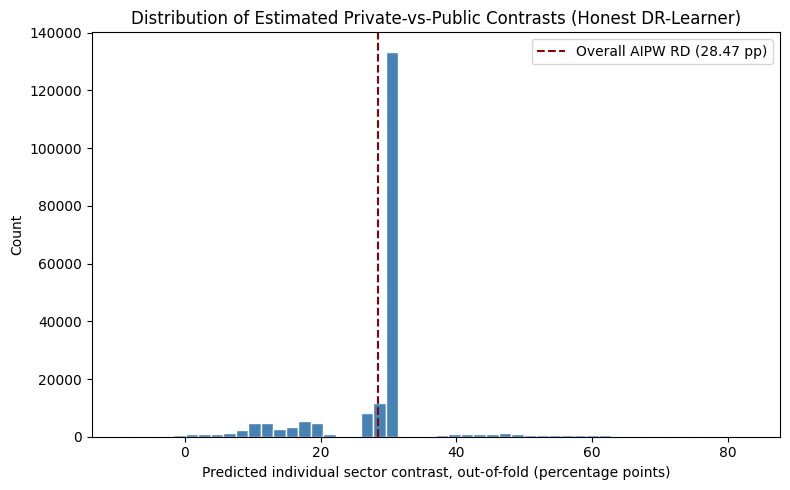

Saved: C:\Users\rifan\Downloads\IPD_SEM_5\IPD\extensions_work\02_causal_heterogeneity\outputs\heterogeneity_distribution.png


In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(tau_oof * 100, bins=50, color="steelblue", edgecolor="white")
ax.axvline(risk_difference * 100, color="darkred", linestyle="--",
           label=f"Overall AIPW RD ({risk_difference*100:.2f} pp)")
ax.set_xlabel("Predicted individual sector contrast, out-of-fold (percentage points)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Estimated Private-vs-Public Contrasts (Honest DR-Learner)")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "heterogeneity_distribution.png", dpi=200)
plt.show()
print("Saved:", OUTPUTS_DIR / "heterogeneity_distribution.png")

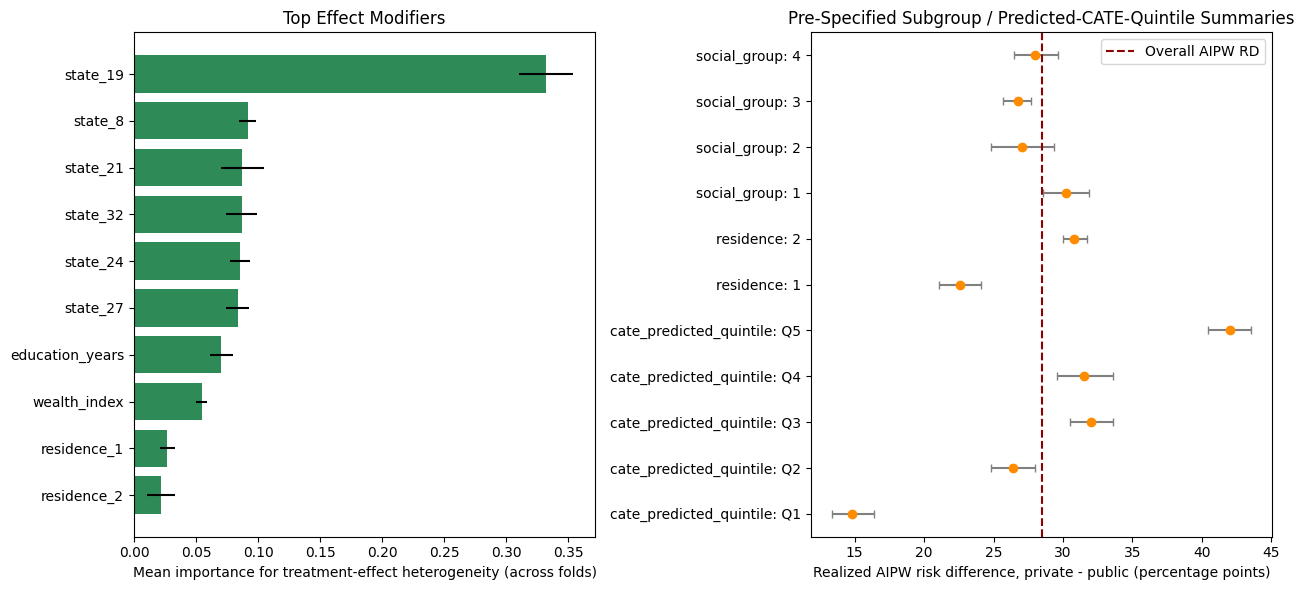

Saved: C:\Users\rifan\Downloads\IPD_SEM_5\IPD\extensions_work\02_causal_heterogeneity\outputs\heterogeneity_subgroups.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

top_modifiers = modifier_summary.head(10).iloc[::-1]
axes[0].barh(top_modifiers["feature"], top_modifiers["importance_mean"],
             xerr=top_modifiers["importance_std"], color="seagreen")
axes[0].set_xlabel("Mean importance for treatment-effect heterogeneity (across folds)")
axes[0].set_title("Top Effect Modifiers")

plot_rows = heterogeneity_summary.sort_values(["grouping_variable", "group_label"])
y_pos = np.arange(len(plot_rows))
axes[1].errorbar(
    plot_rows["realized_aipw_rd_pp"], y_pos,
    xerr=[plot_rows["realized_aipw_rd_pp"] - plot_rows["realized_aipw_rd_ci_low_pp"],
          plot_rows["realized_aipw_rd_ci_high_pp"] - plot_rows["realized_aipw_rd_pp"]],
    fmt="o", color="darkorange", ecolor="gray", capsize=3,
)
axes[1].axvline(risk_difference * 100, color="darkred", linestyle="--", label="Overall AIPW RD")
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(plot_rows["grouping_variable"] + ": " + plot_rows["group_label"].astype(str))
axes[1].set_xlabel("Realized AIPW risk difference, private - public (percentage points)")
axes[1].set_title("Pre-Specified Subgroup / Predicted-CATE-Quintile Summaries")
axes[1].legend()

fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "heterogeneity_subgroups.png", dpi=200)
plt.show()
print("Saved:", OUTPUTS_DIR / "heterogeneity_subgroups.png")

## 14. Save metadata

In [15]:
metadata = {
    "random_state": RANDOM_STATE,
    "reused_notebook07_nuisances": bool(REUSED_NOTEBOOK07_NUISANCES),
    "n_analytic_sample": int(len(analytic)),
    "confounder_set_stage1": confounder_cols,
    "moderator_set_primary": PRIMARY_MODERATORS,
    "maternal_age_sensitivity_enabled": MATERNAL_AGE_SENSITIVITY,
    "stage1_nuisance_models": (
        "identical to notebooks/v2/07 (LogisticRegression propensity, XGBoost S-learner outcome, "
        "survey-weighted, respondent-grouped 5-fold cross-fitting)"
    ),
    "stage2_cate_model": {
        "learner": "RandomForestRegressor(n_estimators=500, max_depth=6, min_samples_leaf=200)",
        "target": "AIPW pseudo-outcome tau_hat = psi1 - psi0 (Kennedy 2020 DR-learner)",
        "cross_fitting": f"GroupKFold(n_splits={CATE_N_FOLDS}), grouped by respondent_id, independent of Stage-1 folds",
        "sample_weight": "sample_weight_normalized",
    },
    "validation": {
        "method": "sorted-quantile-bin (quintile) realized AIPW effect vs. predicted CATE, PSU-cluster bootstrap CI per bin",
        "n_bootstrap_per_bin": config.N_BOOTSTRAP,
    },
    "overall_aipw_estimate": {
        "risk_difference_pct": float(risk_difference * 100),
        "risk_ratio": float(risk_ratio),
    },
    "limitations": [
        "PSU-cluster bootstrap uncertainty is computed per pre-specified subgroup/quantile bin, not by "
        "re-running the full Stage-1 + Stage-2 pipeline inside each bootstrap replicate (computationally "
        "infeasible at this scope) -- so bin-level CIs do not propagate Stage-1/Stage-2 model-selection "
        "uncertainty, only sampling uncertainty given the already-fitted nuisance and CATE models.",
        "The second-stage RandomForestRegressor's own hyperparameters were fixed a priori and not tuned "
        "against tau_hat, to avoid outcome-driven model selection; this trades some predictive power for "
        "honesty.",
    ],
    "interpretation_rule": (
        "Exploratory adjusted-effect heterogeneity only. Not personalized causal truth. Only as credible "
        "as the primary AIPW analysis's selection-on-observables assumption."
    ),
}

with open(OUTPUTS_DIR / "heterogeneity_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)
print("Saved:", OUTPUTS_DIR / "heterogeneity_metadata.json")

Saved: C:\Users\rifan\Downloads\IPD_SEM_5\IPD\extensions_work\02_causal_heterogeneity\outputs\heterogeneity_metadata.json


## 15. Documentation -- key design decisions and why

**Why a DR-learner with `RandomForestRegressor`, not a dedicated causal-forest package.**
`econml`/`grf` are not in the project's `requirements.txt`, and adding either introduces a heavier
dependency tree than this extension needs. Kennedy's (2020) DR-learner is a standard,
peer-reviewed instantiation of "regress the doubly-robust pseudo-outcome on covariates with any
flexible learner," and cross-fitting it exactly as done here (fresh, independent folds for the
second stage) satisfies the handoff's "honest ... with sample splitting/cross-fitting" requirement
without adding a new dependency. `requirements_extensions.txt` therefore adds nothing for this
extension.

**Why the second-stage folds are independent of the Stage-1 (nuisance) folds.**
Reusing the exact same fold split for both stages would let a record's own residual outcome
information leak into its own predicted CATE indirectly through fold correlation. A fresh
`GroupKFold` split (still respondent-grouped, so no respondent's records cross the train/held-out
boundary) keeps the two stages' held-out sets independent.

**Why validation is a sorted-quantile-bin calibration check, not a held-out R-squared.**
`tau_hat` is a noisy, high-variance pseudo-outcome by construction (each record only observes one
potential outcome), so a per-record R-squared against it is not informative. The standard remedy in
the DR-learner/causal-forest literature is to check whether *realized*, independently-estimated AIPW
effects rank in the same order as the model's *predicted* CATE quantiles -- exactly what Section 11
does, honestly, using only out-of-fold predictions.

**Why heterogeneity is reported as a verdict, not asserted.**
Per the handoff's QA rule, if the monotonicity/CI-separation check in Section 12 fails, this notebook
prints and must be reported as weak/null heterogeneity -- the pipeline does not silently retry with a
different moderator set or model until a pattern appears, since that would be exactly the
outcome-driven subgroup search the handoff prohibits (step 17).

**What this does and does not establish.**
This finds *where* the adjusted contrast between private and public facilities appears larger or
smaller across pre-specified, pre-exposure characteristics. It does not establish that any specific
subgroup's facility choice *causes* a different Cesarean risk for that subgroup individually -- that
would require the same measured-confounding assumption as the primary AIPW analysis to hold
*within* every subgroup, which is not separately tested here.